In [10]:
import obspy
from obspy import read
from obspy.clients.fdsn import Client
import matplotlib.pyplot as plt
import warnings

# 忽略不必要的警告，保持 VS Code 界面整洁
warnings.filterwarnings('once')

print(f"✅ ObsPy version: {obspy.__version__} loaded successfully!")

✅ ObsPy version: 1.5.0 loaded successfully!


In [11]:
# 利用通配符读取 data 文件夹下所有的 sac 文件
try:
    st = read("./data/*.sac")
    print(f"✅ 成功读取了 {len(st)} 条波形通道数据！")
    
    # 打印前几条看看基本信息
    print(st.__str__(extended=True)[:500] + "...\n(仅展示部分)")
except Exception as e:
    print(f"❌ 读取失败，请检查路径。错误信息: {e}")

✅ 成功读取了 39 条波形通道数据！
39 Trace(s) in Stream:
II.ALE.00.BHE  | 2008-05-12T06:33:50.149903Z - 2008-05-12T06:57:41.749903Z | 20.0 Hz, 28633 samples
II.ALE.00.BHN  | 2008-05-12T06:33:50.149903Z - 2008-05-12T06:57:41.749903Z | 20.0 Hz, 28633 samples
II.ALE.00.BHZ  | 2008-05-12T06:33:50.149903Z - 2008-05-12T06:57:41.749903Z | 20.0 Hz, 28633 samples
II.ARU.00.BHE  | 2008-05-12T06:30:36.325110Z - 2008-05-12T06:51:43.925110Z | 20.0 Hz, 25353 samples
II.ARU.00.BHN  | 2008-05-12T06:30:36.325080Z - 2008-05-12T06:51:43.925080Z | ...
(仅展示部分)


In [ ]:
print("正在连接 EARTHSCOPE 服务器提取仪器参数，请稍候...")
client = Client("EARTHSCOPE")

# 自动从本地数据中提取所有的台网(Network)和台站(Station)名称
networks = ",".join(list(set([tr.stats.network for tr in st])))
stations = ",".join(list(set([tr.stats.station for tr in st])))

# 请求这些台站的元数据 (包含经纬度、仪器响应)
inv = client.get_stations(network=networks, station=stations,
                          starttime=st[0].stats.starttime,
                          endtime=st[-1].stats.endtime,
                          level="response")

print("✅ 仪器参数 (Inventory) 下载完成！")
print(inv)

正在连接 EARTHSCOPE 服务器提取仪器参数，请稍候...
✅ 仪器参数 (Inventory) 下载完成！
Inventory created at 2026-03-19T17:35:52.707100Z
	Created by: IRIS WEB SERVICE: fdsnws-station | version: 1.1.52
		    https://service.earthscope.org/fdsnws/station/1/query?starttime=200...
	Sending institution: IRIS-DMC (IRIS-DMC)
	Contains:
		Networks (2):
			II, IU
		Stations (13):
			II.ALE (Alert, NU, Canada)
			II.ARU (Arti, Russia)
			II.DGAR (Diego Garcia, Chagos Islands, Indian Ocean)
			II.OBN (Obninsk, Russia)
			II.WRAB (Tennant Creek, NT, Australia)
			IU.ADK (Adak, Aleutian Islands, Alaska)
			IU.COLA (College Outpost, Alaska, USA)
			IU.CTAO (Charters Towers, Australia)
			IU.GUMO (Guam, Mariana Islands)
			IU.KBS (Ny-Alesund, Spitzbergen, Norway)
			IU.KIP (Kipapa, Hawaii, USA)
			IU.PMG (Port Moresby, New Guinea)
			IU.WAKE (Wake Island)
		Channels (350):
			II.ALE.00.BHZ, II.ALE.00.BHN, II.ALE.00.BHE, II.ALE.00.ENZ, 
			II.ALE.00.ENN, II.ALE.00.ENE, II.ALE.00.LHZ, II.ALE.00.LHN, 
			II.ALE.00.LHE, II.ALE.00.LNZ

In [12]:
from obspy.geodetics import gps2dist_azimuth, kilometer2degrees

# 1. 定义汶川地震的震中经纬度 (从 PyWEED 中获取的准确坐标)
evla = 31.064
evlo = 103.372

# 创建一个空的 Stream，用来存放处理好后的数据
st_processed = obspy.Stream()

# 提取出所有台站的名字，准备挨个处理
station_names = list(set([tr.stats.station for tr in st]))
print(f"开始批量处理 {len(station_names)} 个台站的数据...\n" + "-"*40)

for sta in station_names:
    # 把当前台站的 Z, N, E 三个分量挑出来组成一组
    st_sta = st.select(station=sta).copy()
    
    if len(st_sta) < 3:
        print(f"⚠️ 警告：台站 {sta} 分量不全，已跳过。")
        continue
        
    try:
        # ---- 第一步：获取台站的经纬度 (从我们下载的 inv 说明书里查) ----
        coords = inv.get_coordinates(st_sta[0].id)
        stla = coords['latitude']
        stlo = coords['longitude']
        
        # ---- 第二步：常规去噪与合并 ----
        st_sta.detrend('linear')   # 去趋势
        st_sta.detrend('constant') # 去均值
        st_sta.merge(fill_value=0) # 防止有数据断片
        
        # ---- 第三步：去仪器响应 ----
        # output='VEL' 表示把电信号(Count)转换为真实的地表运动速度(m/s)
        st_sta.remove_response(inventory=inv, output='VEL', 
                               pre_filt=(1.0/180, 1.0/150, 4, 5))
        
        # ---- 第四步：计算震中距和方位角 ----
        # dist_m 是震中到台站的表面距离(米)，az 是方位角，baz 是反方位角
        dist_m, az, baz = gps2dist_azimuth(evla, evlo, stla, stlo)
        
        # 将距离(米)转换为地震学常用的角度(度 °)
        dist_deg = kilometer2degrees(dist_m / 1000.0)
        
        # ---- 第五步：坐标系旋转 (NE -> RT) ----
        # 利用反方位角，把南北(N)、东西(E)分量，扭转为径向(R)和切向(T)
        st_sta.rotate(method="NE->RT", back_azimuth=baz)
        
        # ---- 第六步：写头信息 ----
        # 给每条波形打上距离标签，后面画 Record Section 时才能按距离排队
        for tr in st_sta:
            tr.stats.distance = dist_m  # obspy 画图底层需要用到 meters
            
            if not hasattr(tr.stats, 'sac'):
                tr.stats.sac = obspy.core.AttribDict()
            tr.stats.sac.stla = stla
            tr.stats.sac.stlo = stlo
            tr.stats.sac.evla = evla
            tr.stats.sac.evlo = evlo
            tr.stats.sac.gcarc = dist_deg # 震中距(度)
            
        # 把处理好的这 3 个分量装进最终成品库里
        st_processed += st_sta
        print(f"✅ 台站 {sta} 处理完毕 (震中距: {dist_deg:.1f}°)")
        
    except Exception as e:
        print(f"❌ 台站 {sta} 处理时发生错误: {e}")

print("-"*40 + f"\n 全部处理完成！最终获得 {len(st_processed)} 条干净的波形。")

开始批量处理 13 个台站的数据...
----------------------------------------
✅ 台站 KIP 处理完毕 (震中距: 86.2°)
✅ 台站 WAKE 处理完毕 (震中距: 57.8°)
✅ 台站 WRAB 处理完毕 (震中距: 58.8°)
✅ 台站 KBS 处理完毕 (震中距: 60.0°)
✅ 台站 OBN 处理完毕 (震中距: 52.1°)
✅ 台站 DGAR 处理完毕 (震中距: 48.4°)
✅ 台站 ADK 处理完毕 (震中距: 60.2°)
✅ 台站 GUMO 处理完毕 (震中距: 41.9°)
✅ 台站 ARU 处理完毕 (震中距: 40.1°)
✅ 台站 COLA 处理完毕 (震中距: 69.7°)
✅ 台站 PMG 处理完毕 (震中距: 58.2°)
✅ 台站 CTAO 处理完毕 (震中距: 65.5°)
✅ 台站 ALE 处理完毕 (震中距: 66.3°)
----------------------------------------
 全部处理完成！最终获得 39 条干净的波形。


绘制 3D 视角的震源与台站分布图...


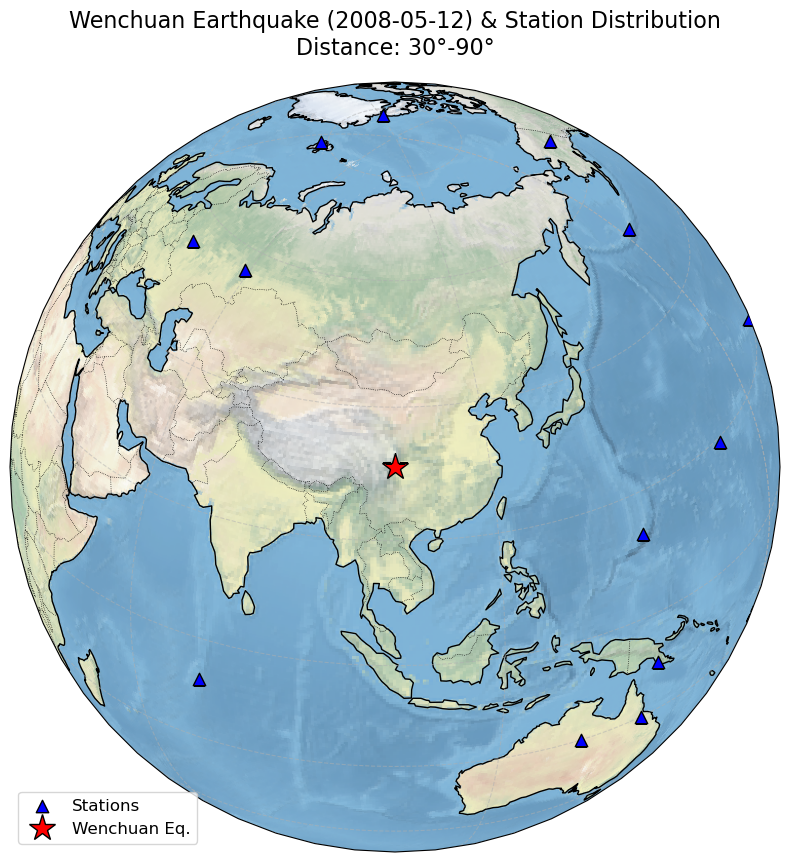

✅ 第一张图 (地图) 绘制并保存成功！


In [14]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os

if not os.path.exists('./figures'):
    os.makedirs('./figures')

print("绘制 3D 视角的震源与台站分布图...")

# 1. 震源坐标 (汶川)
evla = 31.064
evlo = 103.372

# 2. 设置画布和正射投影 (太空俯视视角，以汶川为中心)
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Orthographic(central_longitude=evlo, central_latitude=evla))

# 3. 添加海岸线和地形背景
ax.stock_img() 
ax.add_feature(cfeature.COASTLINE, linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')
ax.gridlines(linestyle='--', alpha=0.5)

# ==========================================
# 4. 提取台站坐标
# ==========================================
station_lats = [tr.stats.sac.stla for tr in st_processed.select(component="Z")]
station_lons =[tr.stats.sac.stlo for tr in st_processed.select(component="Z")]

# 5. 画图最核心的一步：transform=ccrs.Geodetic()

# 5.1 画台站 (蓝色三角形)
ax.scatter(station_lons, station_lats, 
           transform=ccrs.Geodetic(), 
           c='blue', marker='^', s=80, edgecolors='black', label='Stations', zorder=5)

# 5.2 画震源 (红色五角星)
ax.plot(evlo, evla, 
        transform=ccrs.Geodetic(), 
        marker='*', color='red', markersize=20, markeredgecolor='black', 
        linestyle='None',
        label='Wenchuan Eq.', zorder=6)

# 6. 添加图例、标题并保存
ax.legend(loc='lower left', fontsize=12)
plt.title("Wenchuan Earthquake (2008-05-12) & Station Distribution\nDistance: 30°-90°", fontsize=16, pad=20)

plt.savefig('./figures/Figure1_Station_Map.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ 第一张图 (地图) 绘制并保存成功！")

计算理论走时并绘制 Z, R, T 分量波形剖面图


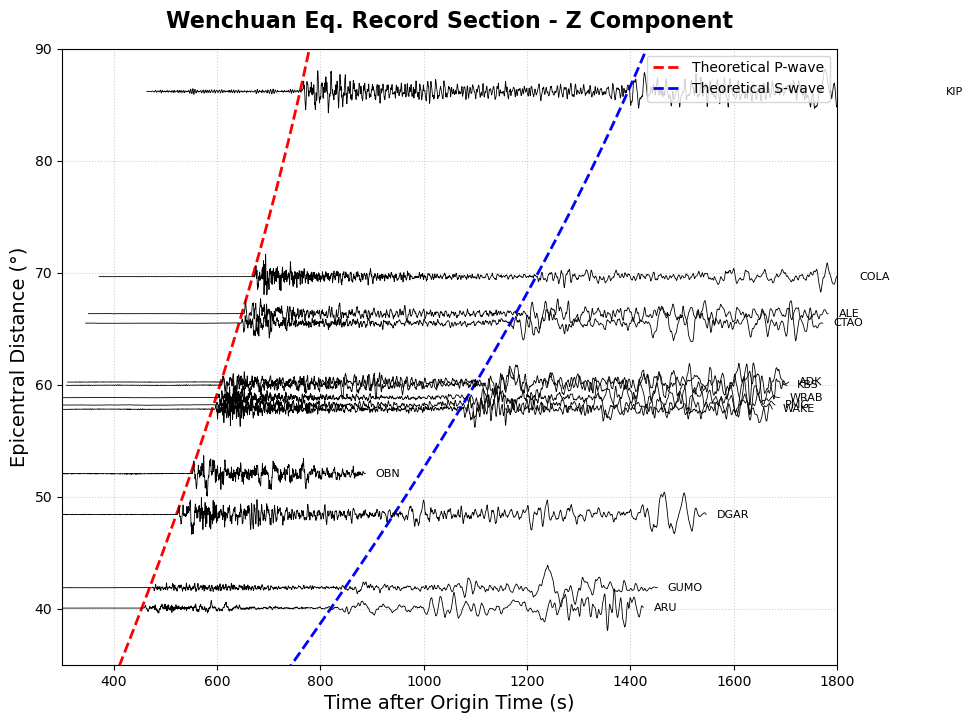

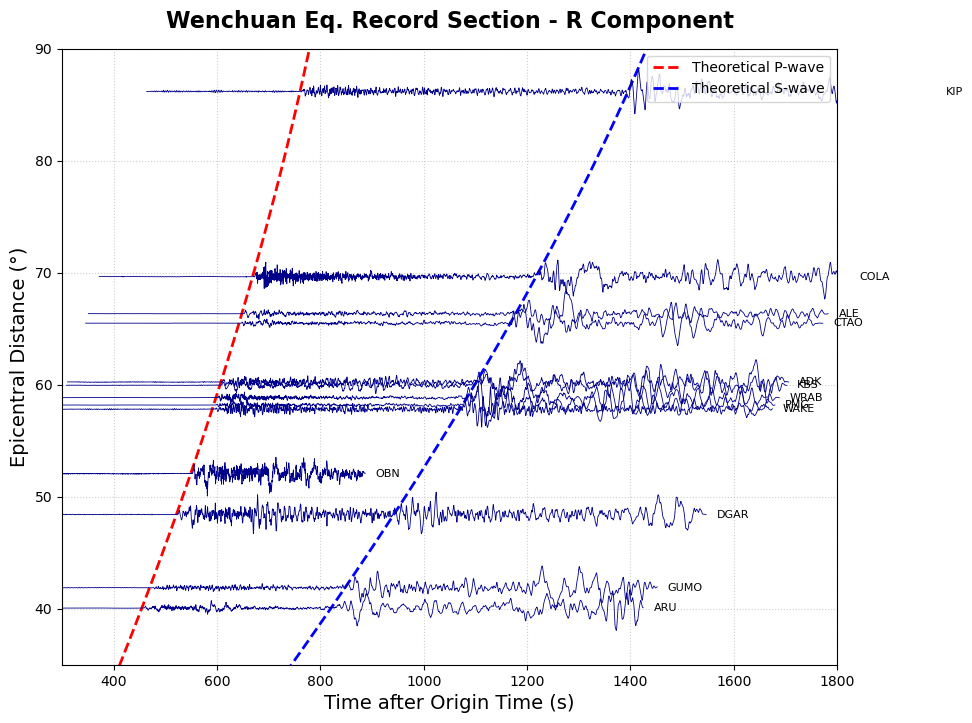

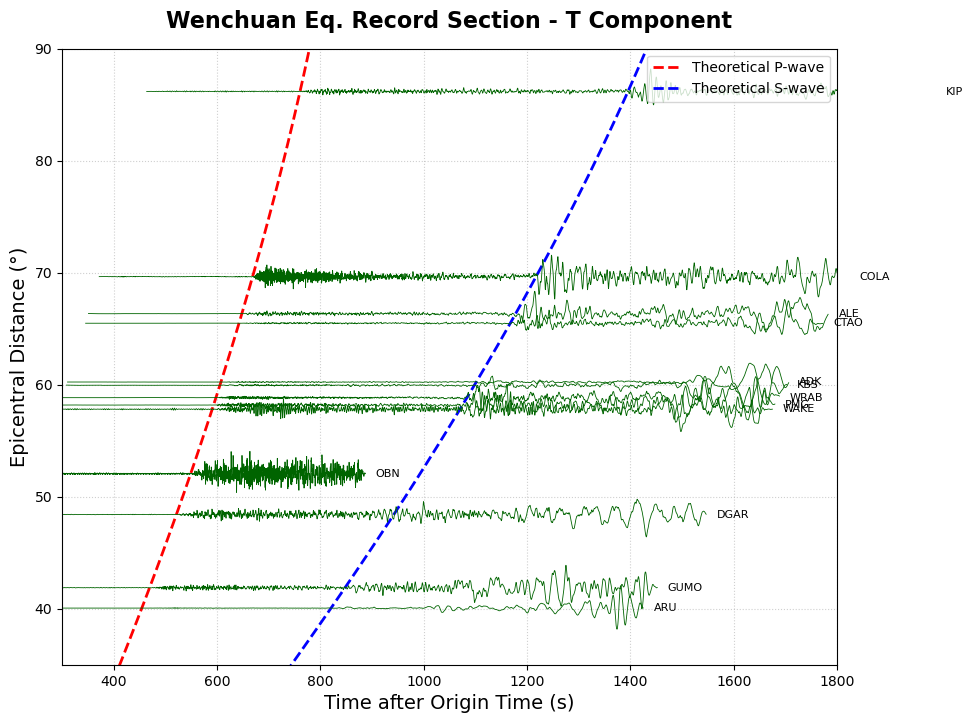

3 张分量剖面图已全部绘制并保存在 figures 文件夹中


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from obspy.taup import TauPyModel
from obspy import UTCDateTime

print("计算理论走时并绘制 Z, R, T 分量波形剖面图")

# 1. 初始化 1D 速度模型 (iasp91 极其经典)
model = TauPyModel(model="iasp91")

origin_time = UTCDateTime("2008-05-12T06:27:59")
# 汶川地震震源深度约为 15 km
depth_km = 15.0 

# 为了画出平滑的理论 P/S 波曲线，我们在 30~90 度之间生成 100 个点
dist_curve = np.linspace(30, 90, 100)
p_curve_times =[]
s_curve_times =[]

# 计算这 100 个距离上的 P 和 S 波理论到达时间 (相对于发震时间的秒数)
for d in dist_curve:
    arrivals = model.get_travel_times(source_depth_in_km=depth_km, distance_in_degree=d, phase_list=["P", "S"])
    # 提取 P 和 S 的时间
    p_time =[a.time for a in arrivals if a.name == 'P']
    s_time =[a.time for a in arrivals if a.name == 'S']
    # 如果有对应的波就存进去，没有就算了
    p_curve_times.append(p_time[0] if p_time else np.nan)
    s_curve_times.append(s_time[0] if s_time else np.nan)

# ==========================================
# 2. 核心大循环：一次性画出 Z, R, T 三张图
# ==========================================
components = ['Z', 'R', 'T']
colors = {'Z': 'black', 'R': 'darkblue', 'T': 'darkgreen'}

for comp in components:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # 提取当前分量（比如所有的 Z 分量）
    st_comp = st_processed.select(component=comp)
    
    # 2.1 先画出理论走时曲线 (底层打底)
    ax.plot(p_curve_times, dist_curve, color='red', linestyle='--', linewidth=2, label='Theoretical P-wave')
    ax.plot(s_curve_times, dist_curve, color='blue', linestyle='--', linewidth=2, label='Theoretical S-wave')
    
    # 2.2 循环把该分量的每条波形画上去
    for tr in st_comp:
        dist = tr.stats.sac.gcarc  # 震中距作为 Y 轴基准线
        
        # 波形的绝对时间轴处理：将波形的点转换为距离“发震时刻”的秒数
        time_offset = tr.stats.starttime - origin_time
        times = tr.times() + time_offset 
        
        # 振幅归一化与放大 (让波形好看地排列在对应的度数上，不重叠)
        # 乘以 2.0 表示把波形的最大振幅限制在上下 2 度的宽度内
        data = tr.data
        data_norm = (data / np.max(np.abs(data))) * 2.0 
        
        # 画出波形！横坐标是时间，纵坐标是 (基准度数 + 振幅起伏)
        ax.plot(times, data_norm + dist, color=colors[comp], linewidth=0.6)
        
        # 在每条波形的最右边标上台站名字，显得很专业
        ax.text(times[-1] + 20, dist, tr.stats.station, verticalalignment='center', fontsize=8)

    # 3. 设置美观的图表格式
    ax.set_title(f"Wenchuan Eq. Record Section - {comp} Component", fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel("Time after Origin Time (s)", fontsize=14)
    ax.set_ylabel("Epicentral Distance (°)", fontsize=14)
    
    # 限制坐标轴范围，让波形填满画面
    ax.set_xlim(300, 1800) # 只看 P 波前和 S 波后的核心时间段
    ax.set_ylim(35, 90)
    
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper right')
    
    plt.savefig(f'./figures/Figure{components.index(comp)+2}_Section_{comp}.png', dpi=300, bbox_inches='tight')
    plt.show()

print("3 张分量剖面图已全部绘制并保存在 figures 文件夹中")